In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
NOTIONAL_CONTRACTS = {
    "atm_call": 1,
    "atm_put": 1,
    "otm_call": 1,
    "otm_put": 1
}

In [50]:
def import_data():
    session_signals_long = pd.read_csv('data/session_signals_long.csv')
    session_signals_short = pd.read_csv('data/session_signals_short.csv')
    options_df = pd.read_csv("data/options_df.csv")
    btc_prices = pd.read_csv('data/btc_prices.csv')
    btc_prices.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
    return session_signals_short, session_signals_long, options_df, btc_prices

In [112]:
def construct_short_trades(session_signals, options_df):
    positive_signals = session_signals[session_signals['signal']]
    trades_df = options_df[options_df['session_start'].isin(positive_signals['session_start'])].copy()

    trades_df['position'] = np.select(
        [
            trades_df['leg'].str.startswith('atm'),
            trades_df['leg'].str.startswith('otm')
        ],
        ['short', 'long'],
        default=None
    )

    trades_df['contracts'] = trades_df['leg'].map(NOTIONAL_CONTRACTS)

    if trades_df['contracts'].isna().any():
        missing = trades_df.loc[trades_df['contracts'].isna(), 'leg'].unique()
        raise ValueError(f"Unmapped legs found in NOTIONAL_CONTRACTS: {missing}")

    if trades_df['position'].isna().any():
        bad = trades_df.loc[trades_df['position'].isna(), 'leg'].unique()
        raise ValueError(f"Unclassified legs: {bad}")

    cols = [
        'session_start', 'session_type', 'session_dow', 'leg', 'strike', 'option_type',
        'position', 'entry_price', 'expiry', 'contracts'
    ]

    trades_df = trades_df[cols]
    return trades_df

In [119]:
def calculate_short_exit_price_and_pnl(trades_df, btc_prices):
    btc_prices_keyed = btc_prices[['time', 'close']].rename(
        columns={'time': 'expiry', 'close': 'spot_at_expiry'}
    )
    
    trades_df = trades_df.merge(
        btc_prices_keyed,
        on='expiry',
        how='left'
    )

    if trades_df['spot_at_expiry'].isna().any():
        missing = trades_df.loc[trades_df['spot_at_expiry'].isna(), 'expiry'].unique()
        raise ValueError(f"Missing BTC prices for expiries: {missing}")
    
    spot = trades_df['spot_at_expiry']
    strike = trades_df['strike']

    call_payoff = np.maximum(spot - strike, 0)
    put_payoff  = np.maximum(strike - spot, 0)

    trades_df['exit_price'] = np.select(
        [
            trades_df['option_type'] == 'C',
            trades_df['option_type'] == 'P'
        ],
        [
            call_payoff,
            put_payoff
        ],
        default=np.nan
    )

    trades_df['position_sign'] = trades_df['position'].map({'short': -1, 'long': 1})

    trades_df['pnl'] = (
        (trades_df['exit_price'] - (trades_df['entry_price'] * trades_df['spot_at_expiry']))
        * trades_df['contracts']
        * trades_df['position_sign']
    )

    trades_df.drop(columns=['position_sign'], inplace=True)

    return trades_df

In [105]:
def summarise_short_pnl(trades_df):
    trades_df['premium_component'] = np.where(
        trades_df['position'] == 'short',
        trades_df['entry_price'],
        0
    )

    trades_df['hedge_component'] = np.where(
        trades_df['position'] == 'long',
        trades_df['entry_price'],
        0
    )

    agg = trades_df.groupby('session_start').agg(
        session_dow=('session_dow', 'first'),
        gross_pnl_usd=('pnl', 'sum'),
        premium_sum=('premium_component', 'sum'),
        hedge_sum=('hedge_component', 'sum'),
        spot_at_expiry=('spot_at_expiry', 'first')  # assumes constant per session
    )

    agg = agg.sort_values('session_start')

    agg['premiums_received'] = agg['premium_sum'] * agg['spot_at_expiry']
    agg['hedge_cost'] = agg['hedge_sum'] * agg['spot_at_expiry']
    agg['net_entry_premium'] = agg['premiums_received'] - agg['hedge_cost']

    agg['cumulative_pnl_usd'] = agg['gross_pnl_usd'].cumsum()

    pnl_df = agg.reset_index()[[
        'session_start',
        'session_dow',
        'gross_pnl_usd',
        'premiums_received',
        'hedge_cost',
        'net_entry_premium',
        'cumulative_pnl_usd'
    ]]
    
    return pnl_df

In [201]:
session_signals_short, session_signals_long, options_df, btc_prices = import_data()

In [113]:
trades_df = construct_short_trades(session_signals_short, options_df)
trades_df = calculate_short_exit_price_and_pnl(trades_df,btc_prices)
trades_df.to_csv("data/trades_df_short.csv", index=False)
trades_df

,session_start,session_type,session_dow,leg,strike,option_type,position,entry_price,expiry,contracts,spot_at_expiry,exit_price,pnl
0,2023-01-03 08:00:00+00:00,weekday,tuesday,atm_call,16750.0,C,short,0.0040,2023-01-04 08:00:00+00:00,1,16858.90,108.90,-41.464400
1,2023-01-03 08:00:00+00:00,weekday,tuesday,atm_put,16750.0,P,short,0.0055,2023-01-04 08:00:00+00:00,1,16858.90,0.00,92.723950
2,2023-01-03 08:00:00+00:00,weekday,tuesday,otm_call,17250.0,C,long,0.0005,2023-01-04 08:00:00+00:00,1,16858.90,0.00,-8.429450
3,2023-01-03 08:00:00+00:00,weekday,tuesday,otm_put,16250.0,P,long,0.0005,2023-01-04 08:00:00+00:00,1,16858.90,0.00,-8.429450
4,2023-01-04 08:00:00+00:00,weekday,wednesday,atm_call,16750.0,C,short,0.0100,2023-01-05 08:00:00+00:00,1,16804.35,54.35,113.693500
...,...,...,...,...,...,...,...,...,...,...,...,...,...
391,2025-12-21 08:00:00+00:00,weekend,sunday,otm_put,82000.0,P,long,0.0001,2025-12-22 08:00:00+00:00,1,89293.99,0.00,-8.929399
392,2025-12-28 08:00:00+00:00,weekend,sunday,atm_call,88000.0,C,short,0.0055,2025-12-29 08:00:00+00:00,1,89447.93,1447.93,-955.966385
393,2025-12-28 08:00:00+00:00,weekend,sunday,atm_put,88000.0,P,short,0.0085,2025-12-29 08:00:00+00:00,1,89447.93,0.00,760.307405
394,2025-12-28 08:00:00+00:00,weekend,sunday,otm_call,92000.0,C,long,0.0001,2025-12-29 08:00:00+00:00,1,89447.93,0.00,-8.944793


In [114]:
pnl_df = summarise_short_pnl(trades_df)
pnl_df

,session_start,session_dow,gross_pnl_usd,premiums_received,hedge_cost,net_entry_premium,cumulative_pnl_usd
0,2023-01-03 08:00:00+00:00,tuesday,34.400650,160.159550,16.858900,143.300650,34.400650
1,2023-01-04 08:00:00+00:00,wednesday,130.497850,201.652200,16.804350,184.847850,164.898500
2,2023-01-06 08:00:00+00:00,friday,0.664235,194.661305,16.927070,177.734235,165.562735
3,2023-01-07 08:00:00+00:00,saturday,47.132760,118.618220,16.945460,101.672760,212.695495
4,2023-01-08 08:00:00+00:00,sunday,-63.169175,146.132935,17.192110,128.940825,149.526320
...,...,...,...,...,...,...,...
94,2025-10-26 08:00:00+00:00,sunday,-1441.215182,1610.400540,23.005722,1587.394818,22318.217427
95,2025-12-07 08:00:00+00:00,sunday,-1189.128780,1699.082365,45.921145,1653.161220,21129.088647
96,2025-12-14 08:00:00+00:00,sunday,1181.420400,1436.352000,26.931600,1409.420400,22310.509047
97,2025-12-21 08:00:00+00:00,sunday,1063.278648,1375.127446,17.858798,1357.268648,23373.787695


Long trades

In [124]:
def construct_long_trades(session_signals, options_df):
    positive_signals = session_signals[session_signals["signal"]].copy()

    trades_df = options_df[
        options_df["session_start"].isin(positive_signals["session_start"])
    ].copy()

    trades_df = trades_df[trades_df["leg"].str.startswith("atm")].copy()

    trades_df["position"] = "long"

    # Contracts / notional sizing
    trades_df["contracts"] = trades_df["leg"].map(NOTIONAL_CONTRACTS)

    if trades_df["contracts"].isna().any():
        missing = trades_df.loc[trades_df["contracts"].isna(), "leg"].unique()
        raise ValueError(f"Unmapped legs found in NOTIONAL_CONTRACTS: {missing}")

    cols = [
        "session_start", "session_type", "session_dow", "leg", "strike", "option_type",
        "position", "entry_price", "expiry", "contracts"
    ]

    trades_df = trades_df[cols].reset_index(drop=True)
    return trades_df

In [125]:
def calculate_long_exit_price_and_pnl(trades_df, btc_prices):
    # Map expiry timestamp to spot price at expiry
    btc_prices_keyed = btc_prices[["time", "close"]].rename(
        columns={"time": "expiry", "close": "spot_at_expiry"}
    )

    trades_df = trades_df.merge(
        btc_prices_keyed,
        on="expiry",
        how="left"
    )

    if trades_df["spot_at_expiry"].isna().any():
        missing = trades_df.loc[trades_df["spot_at_expiry"].isna(), "expiry"].unique()
        raise ValueError(f"Missing BTC prices for expiries: {missing}")

    spot = trades_df["spot_at_expiry"]
    strike = trades_df["strike"]

    # Intrinsic value at expiry in USD terms
    call_payoff_usd = np.maximum(spot - strike, 0.0)
    put_payoff_usd = np.maximum(strike - spot, 0.0)

    # Convert intrinsic value to BTC terms, since BTC options are often quoted in BTC
    call_payoff_btc = call_payoff_usd / spot
    put_payoff_btc = put_payoff_usd / spot

    trades_df["exit_price"] = np.select(
        [
            trades_df["option_type"] == "C",
            trades_df["option_type"] == "P"
        ],
        [
            call_payoff_btc,
            put_payoff_btc
        ],
        default=np.nan
    )

    if trades_df["exit_price"].isna().any():
        bad = trades_df.loc[trades_df["exit_price"].isna(), "option_type"].unique()
        raise ValueError(f"Unclassified option types: {bad}")

    # Long straddle: both legs are long
    trades_df["position_sign"] = 1

    trades_df["pnl"] = (
        (trades_df["exit_price"] - trades_df["entry_price"] * trades_df["spot_at_expiry"])
        * trades_df["contracts"]
        * trades_df["position_sign"]
    )

    trades_df.drop(columns=["position_sign"], inplace=True)

    return trades_df

In [127]:
def summarise_long_pnl(trades_df):
    trades_df = trades_df.copy()

    # For a long straddle, all legs are long and all entry premium is paid
    trades_df['premium_paid_component'] = trades_df['entry_price']
    trades_df['premium_received_component'] = 0.0

    agg = trades_df.groupby('session_start').agg(
        session_dow=('session_dow', 'first'),
        gross_pnl_usd=('pnl', 'sum'),
        premium_paid=('premium_paid_component', 'sum'),
        premium_received=('premium_received_component', 'sum'),
        spot_at_expiry=('spot_at_expiry', 'first')  # should be constant within session
    )

    agg = agg.sort_values('session_start')

    # Since the whole position is long, net entry premium is just what you paid
    agg['net_entry_premium'] = agg['premium_received'] - agg['premium_paid']

    # If you want the cumulative strategy PnL over time
    agg['cumulative_pnl_usd'] = agg['gross_pnl_usd'].cumsum()

    pnl_df = agg.reset_index()[[
        'session_start',
        'session_dow',
        'gross_pnl_usd',
        'premium_paid',
        'premium_received',
        'net_entry_premium',
        'cumulative_pnl_usd'
    ]]

    return pnl_df

In [126]:
trades_df_long = construct_long_trades(session_signals_long, options_df)
trades_df_long = calculate_short_exit_price_and_pnl(trades_df_long,btc_prices)
trades_df_long.to_csv("data/trades_df_long.csv", index=False)
trades_df_long

,session_start,session_type,session_dow,leg,strike,option_type,position,entry_price,expiry,contracts,spot_at_expiry,exit_price,pnl
0,2023-01-10 08:00:00+00:00,weekday,tuesday,atm_call,17250.0,C,long,0.0030,2023-01-11 08:00:00+00:00,1,17449.45,199.45,147.101650
1,2023-01-10 08:00:00+00:00,weekday,tuesday,atm_put,17250.0,P,long,0.0060,2023-01-11 08:00:00+00:00,1,17449.45,0.00,-104.696700
2,2023-02-10 08:00:00+00:00,weekday,friday,atm_call,22000.0,C,long,0.0050,2023-02-11 08:00:00+00:00,1,21688.72,0.00,-108.443600
3,2023-02-10 08:00:00+00:00,weekday,friday,atm_put,22000.0,P,long,0.0090,2023-02-11 08:00:00+00:00,1,21688.72,311.28,116.081520
4,2023-02-15 08:00:00+00:00,weekday,wednesday,atm_call,22000.0,C,long,0.0110,2023-02-16 08:00:00+00:00,1,24583.39,2583.39,2312.972710
...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,2025-12-19 08:00:00+00:00,weekday,friday,atm_put,88000.0,P,long,0.0105,2025-12-20 08:00:00+00:00,1,88213.64,0.00,-926.243220
480,2025-12-26 08:00:00+00:00,weekday,friday,atm_call,89000.0,C,long,0.0060,2025-12-27 08:00:00+00:00,1,87530.31,0.00,-525.181860
481,2025-12-26 08:00:00+00:00,weekday,friday,atm_put,89000.0,P,long,0.0090,2025-12-27 08:00:00+00:00,1,87530.31,1469.69,681.917210
482,2025-12-27 08:00:00+00:00,weekend,saturday,atm_call,88000.0,C,long,0.0007,2025-12-28 08:00:00+00:00,1,87736.16,0.00,-61.415312


In [129]:
pnl_df_long = summarise_long_pnl(trades_df_long)
pnl_df_long

,session_start,session_dow,gross_pnl_usd,premium_paid,premium_received,net_entry_premium,cumulative_pnl_usd
0,2023-01-10 08:00:00+00:00,tuesday,42.404950,0.0090,0.0,-0.0090,42.404950
1,2023-02-10 08:00:00+00:00,friday,7.637920,0.0140,0.0,-0.0140,50.042870
2,2023-02-15 08:00:00+00:00,wednesday,2177.764065,0.0165,0.0,-0.0165,2227.806935
3,2023-03-05 08:00:00+00:00,sunday,-125.783060,0.0130,0.0,-0.0130,2102.023875
4,2023-03-28 08:00:00+00:00,tuesday,477.848880,0.0220,0.0,-0.0220,2579.872755
...,...,...,...,...,...,...,...
234,2025-12-13 08:00:00+00:00,saturday,-536.078586,0.0074,0.0,-0.0074,26595.774636
235,2025-12-16 08:00:00+00:00,tuesday,-1365.445800,0.0200,0.0,-0.0200,25230.328836
236,2025-12-19 08:00:00+00:00,friday,-1506.525980,0.0195,0.0,-0.0195,23723.802856
237,2025-12-26 08:00:00+00:00,friday,156.735350,0.0150,0.0,-0.0150,23880.538206


#### Subtask 8

In [115]:
def compute_stats(session_signals, pnl_df):
    session_signals = session_signals.copy()

    if session_signals["session_start"].dtype == object:
        session_signals["session_start"] = pd.to_datetime(
            session_signals["session_start"],
            utc=True
        )

    # Ensure session_dow exists and is lowercase
    if "session_dow" not in session_signals.columns:
        session_signals["session_dow"] = (
            session_signals["session_start"]
            .dt.day_name()
            .str.lower()
        )
    else:
        session_signals["session_dow"] = session_signals["session_dow"].str.lower()

    weekend_vrp = session_signals.loc[
        session_signals["session_type"] == "weekend",
        "vrp"
    ].dropna()

    weekday_vrp = session_signals.loc[
        session_signals["session_type"] == "weekday",
        "vrp"
    ].dropna()

    mean_vrp_weekend = weekend_vrp.mean()
    mean_vrp_weekday = weekday_vrp.mean()

    # One-sided: is mean VRP > 0?
    t_stat_weekend, p_value_weekend = stats.ttest_1samp(
        weekend_vrp,
        0.0,
        alternative="greater"
    )

    t_stat_weekday, p_value_weekday = stats.ttest_1samp(
        weekday_vrp,
        0.0,
        alternative="greater"
    )

    # Two-sided: is weekend VRP != weekday VRP?
    t_stat_diff, p_value_diff = stats.ttest_ind(
        weekend_vrp,
        weekday_vrp,
        equal_var=False
    )

    pnl_typed = pnl_df.merge(
        session_signals[
            ["session_start", "session_type", "session_dow"]
        ].astype({"session_start": str}),
        left_on=pnl_df["session_start"].astype(str),
        right_on="session_start",
        how="left",
        suffixes=("", "_y")
    ).drop(columns=["key_0", "session_start_y"], errors="ignore")

    def sharpe(series, ann_factor):
        s = series.dropna()
        if len(s) < 2 or s.std(ddof=1) == 0:
            return np.nan
        return s.mean() / s.std(ddof=1) * np.sqrt(ann_factor)

    weekend_pnl = pnl_typed.loc[
        pnl_typed["session_type"] == "weekend",
        "gross_pnl_usd"
    ]

    weekday_pnl = pnl_typed.loc[
        pnl_typed["session_type"] == "weekday",
        "gross_pnl_usd"
    ]

    sharpe_weekend = sharpe(weekend_pnl, 52)
    sharpe_weekday = sharpe(weekday_pnl, 104)

    # -----------------------------
    # Day-of-week stats
    # -----------------------------
    day_order = [
        "monday", "tuesday", "wednesday", "thursday",
        "friday", "saturday", "sunday"
    ]

    dow_results = {}

    for day in day_order:
        day_vrp = session_signals.loc[
            session_signals["session_dow"] == day,
            "vrp"
        ].dropna()

        day_pnl = pnl_typed.loc[
            pnl_typed["session_dow"] == day,
            "gross_pnl_usd"
        ].dropna()

        if len(day_vrp) >= 2:
            t_day, p_day = stats.ttest_1samp(
                day_vrp,
                0.0,
                alternative="greater"
            )
        else:
            t_day, p_day = np.nan, np.nan

        dow_results[day] = {
            "n_vrp": len(day_vrp),
            "mean_vrp": day_vrp.mean(),
            "t_stat_vrp_gt_0": t_day,
            "p_value_vrp_gt_0": p_day,
            "n_pnl": len(day_pnl),
            "mean_pnl": day_pnl.mean(),
            "total_pnl": day_pnl.sum(),
            "sharpe": sharpe(day_pnl, 52),
        }

    stats_results = {
        "mean_vrp_weekend": mean_vrp_weekend,
        "mean_vrp_weekday": mean_vrp_weekday,
        "t_stat_weekend": t_stat_weekend,
        "p_value_weekend": p_value_weekend,
        "t_stat_weekday": t_stat_weekday,
        "p_value_weekday": p_value_weekday,
        "t_stat_diff": t_stat_diff,
        "p_value_diff": p_value_diff,
        "sharpe_weekend": sharpe_weekend,
        "sharpe_weekday": sharpe_weekday,
        "dow_results": dow_results,
    }

    print("=== VRP Statistical Analysis ===")
    print(f"n weekend sessions: {len(weekend_vrp)}, n weekday sessions: {len(weekday_vrp)}")
    print(f"Mean VRP weekend: {mean_vrp_weekend:.4f}")
    print(f"Mean VRP weekday: {mean_vrp_weekday:.4f}")
    print()

    print("One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):")
    print(f"  Weekend: t = {t_stat_weekend:.3f}, p = {p_value_weekend:.4f}")
    print(f"  Weekday: t = {t_stat_weekday:.3f}, p = {p_value_weekday:.4f}")
    print()

    print("Two-sided Welch t-test (H0: weekend VRP = weekday VRP):")
    print(f"  t = {t_stat_diff:.3f}, p = {p_value_diff:.4f}")
    print()

    print("Annualised Sharpe (gross_pnl_usd):")
    print(f"  Weekend (sqrt(52)):  {sharpe_weekend:.3f}  (n={len(weekend_pnl.dropna())})")
    print(f"  Weekday (sqrt(104)): {sharpe_weekday:.3f}  (n={len(weekday_pnl.dropna())})")
    print()

    print("=== Day-of-week breakdown ===")
    for day in day_order:
        r = dow_results[day]
        print(
            f"  {day.capitalize():<9} | "
            f"Mean VRP: {r['mean_vrp']:>8.4f} | "
            f"t: {r['t_stat_vrp_gt_0']:>7.3f} | "
            f"p: {r['p_value_vrp_gt_0']:>7.4f} | "
            f"Sharpe sqrt(52): {r['sharpe']:>7.3f} | "
            f"Mean PnL: {r['mean_pnl']:>9.2f} | "
            f"Total PnL: {r['total_pnl']:>10.2f} | "
            f"n={r['n_pnl']}"
        )

    return stats_results

In [116]:
stats_results = compute_stats(session_signals_short, pnl_df)
stats_results

=== VRP Statistical Analysis ===
n weekend sessions: 313, n weekday sessions: 788
Mean VRP weekend: -0.0241
Mean VRP weekday: -0.0046

One-sided one-sample t-test (H0: mean VRP <= 0, H1: mean VRP > 0):
  Weekend: t = -2.914, p = 0.9981
  Weekday: t = -0.715, p = 0.7625

Two-sided Welch t-test (H0: weekend VRP = weekday VRP):
  t = -1.852, p = 0.0644

Annualised Sharpe (gross_pnl_usd):
  Weekend (sqrt(52)):  -0.032  (n=29)
  Weekday (sqrt(104)): 2.816  (n=70)

=== Day-of-week breakdown ===
  Monday    | Mean VRP:  -0.0249 | t:  -1.674 | p:  0.9520 | Sharpe sqrt(52):   2.720 | Mean PnL:    403.88 | Total PnL:    5250.47 | n=13
  Tuesday   | Mean VRP:  -0.0117 | t:  -0.842 | p:  0.7994 | Sharpe sqrt(52):   5.619 | Mean PnL:    716.82 | Total PnL:   10035.42 | n=14
  Wednesday | Mean VRP:   0.0012 | t:   0.077 | p:  0.4695 | Sharpe sqrt(52):   1.759 | Mean PnL:    277.51 | Total PnL:    5550.29 | n=20
  Thursday  | Mean VRP:  -0.0205 | t:  -1.318 | p:  0.9053 | Sharpe sqrt(52):  -0.738 | M

{'mean_vrp_weekend': np.float64(-0.024114676838008463),
 'mean_vrp_weekday': np.float64(-0.004637206972815498),
 't_stat_weekend': np.float64(-2.914325943871403),
 'p_value_weekend': np.float64(0.9980888485733964),
 't_stat_weekday': np.float64(-0.7145696670879167),
 'p_value_weekday': np.float64(0.7624565563214565),
 't_stat_diff': np.float64(-1.85221390491091),
 'p_value_diff': np.float64(0.06441133908781439),
 'sharpe_weekend': np.float64(-0.032351066569062996),
 'sharpe_weekday': np.float64(2.8158253803021527),
 'dow_results': {'monday': {'n_vrp': 158,
   'mean_vrp': np.float64(-0.024861562666331834),
   't_stat_vrp_gt_0': np.float64(-1.6744383332725237),
   'p_value_vrp_gt_0': np.float64(0.951982311767166),
   'n_pnl': 13,
   'mean_pnl': np.float64(403.88261392307675),
   'total_pnl': np.float64(5250.473980999997),
   'sharpe': np.float64(2.72044664861858)},
  'tuesday': {'n_vrp': 157,
   'mean_vrp': np.float64(-0.011671834563952915),
   't_stat_vrp_gt_0': np.float64(-0.8418344736

#### Subtask 9

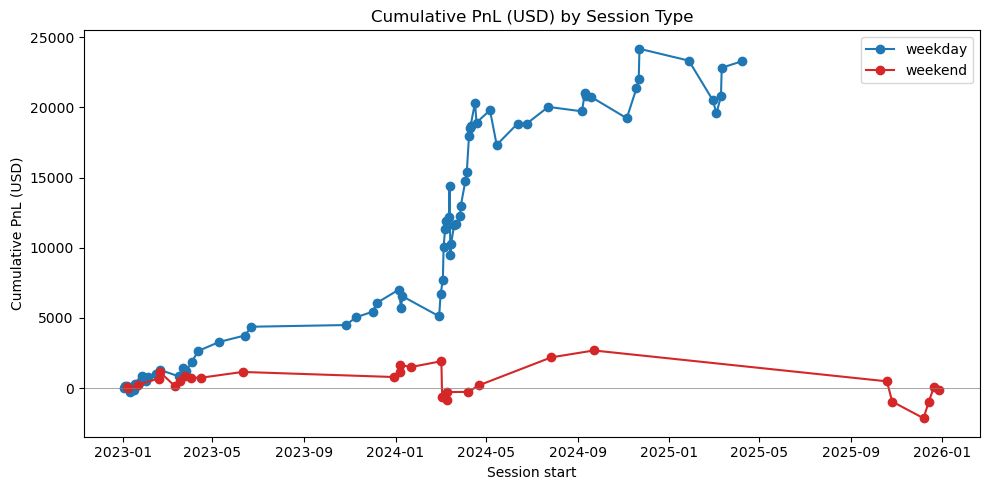

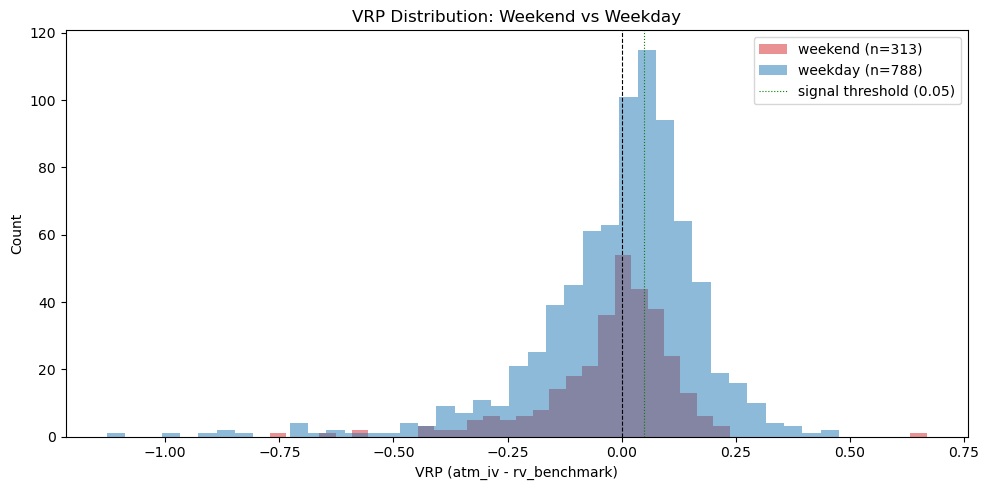

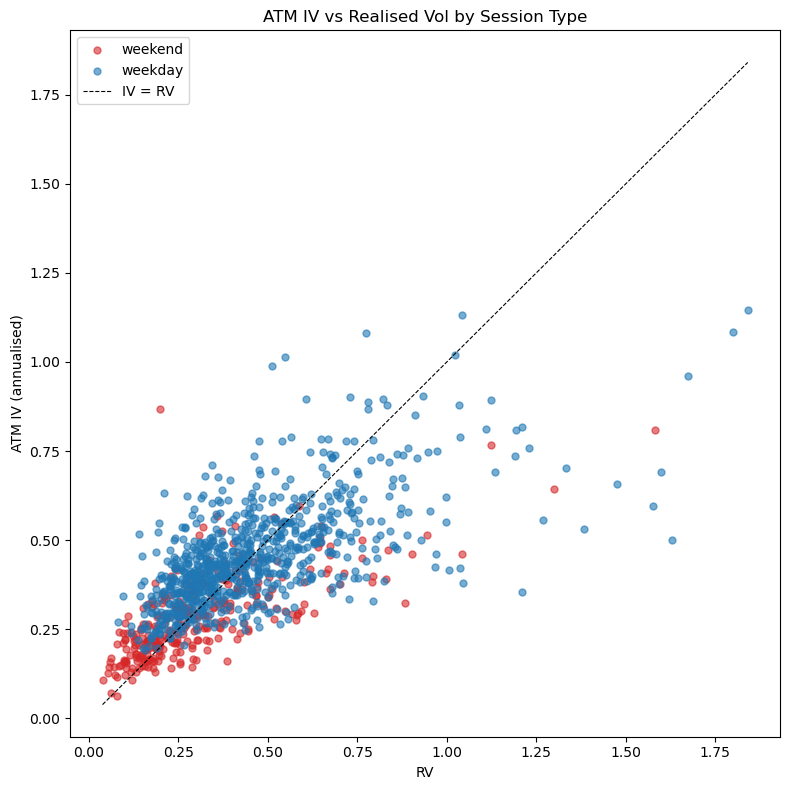

/var/folders/15/jzr9_46j5nl281sqf5zhdsw80000gn/T/ipykernel_26538/1487887271.py:51: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  sig['month'] = sig['session_start'].dt.to_period('M').astype(str)


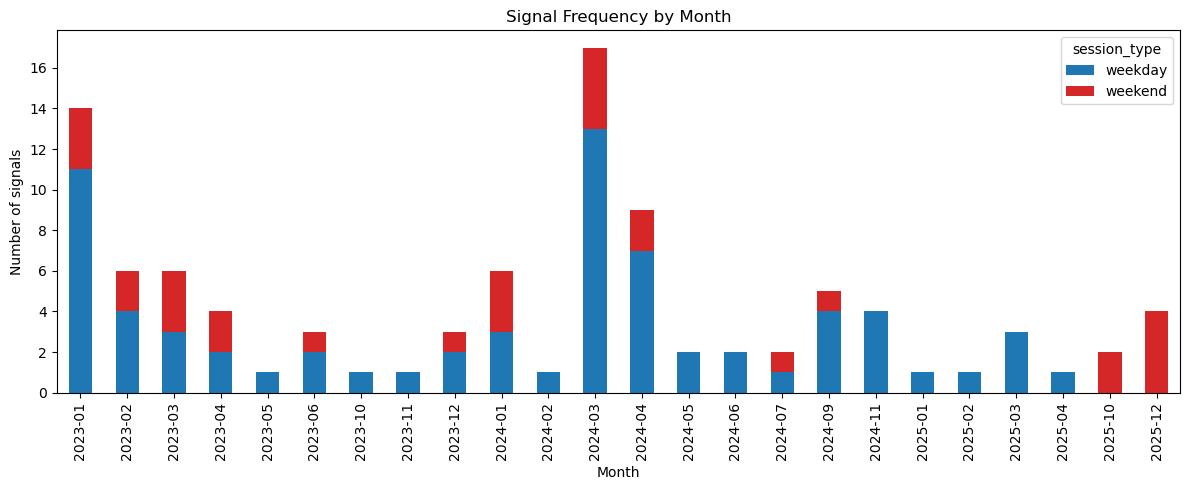

In [117]:
def make_charts(session_signals, trades_df, pnl_df):
    ss = session_signals.copy()
    ss['session_start'] = pd.to_datetime(ss['session_start'], utc=True)

    pnl = pnl_df.copy()
    pnl['session_start'] = pd.to_datetime(pnl['session_start'], utc=True)
    pnl = pnl.merge(ss[['session_start', 'session_type']], on='session_start', how='left')
    pnl = pnl.sort_values('session_start')

    palette = {'weekend': '#d62728', 'weekday': '#1f77b4'}

    # 1. Cumulative PnL (USD) by session type
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype, grp in pnl.groupby('session_type'):
        grp = grp.sort_values('session_start').copy()
        grp['cum'] = grp['gross_pnl_usd'].cumsum()
        ax.plot(grp['session_start'], grp['cum'], marker='o', label=stype, color=palette.get(stype))
    ax.set_title('Cumulative PnL (USD) by Session Type')
    ax.set_xlabel('Session start'); ax.set_ylabel('Cumulative PnL (USD)')
    ax.axhline(0, color='grey', lw=0.5); ax.legend(); fig.tight_layout()
    plt.show()

    # 2. VRP distribution histogram, weekend vs weekday overlaid
    fig, ax = plt.subplots(figsize=(10, 5))
    for stype in ['weekend', 'weekday']:
        vals = ss.loc[ss['session_type'] == stype, 'vrp'].dropna()
        ax.hist(vals, bins=40, alpha=0.5, label=f'{stype} (n={len(vals)})', color=palette[stype])
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.axvline(0.05, color='green', lw=0.8, linestyle=':', label='signal threshold (0.05)')
    ax.set_title('VRP Distribution: Weekend vs Weekday')
    ax.set_xlabel('VRP (atm_iv - rv_benchmark)'); ax.set_ylabel('Count')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 3. IV vs RV scatter, coloured by session type
    fig, ax = plt.subplots(figsize=(8, 8))
    for stype in ['weekend', 'weekday']:
        sub = ss[ss['session_type'] == stype]
        ax.scatter(sub['rv_benchmark'], sub['atm_iv'], alpha=0.6, label=stype,
                   color=palette[stype], s=25)
    lo = min(ss['rv_benchmark'].min(), ss['atm_iv'].min())
    hi = max(ss['rv_benchmark'].max(), ss['atm_iv'].max())
    ax.plot([lo, hi], [lo, hi], color='black', lw=0.8, linestyle='--', label='IV = RV')
    ax.set_title('ATM IV vs Realised Vol by Session Type')
    ax.set_xlabel('RV'); ax.set_ylabel('ATM IV (annualised)')
    ax.legend(); fig.tight_layout()
    plt.show()

    # 4. Signal frequency by month
    sig = ss[ss['signal'].astype(bool)].copy()
    sig['month'] = sig['session_start'].dt.to_period('M').astype(str)
    counts = sig.groupby(['month', 'session_type']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 5))
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[palette.get(c, 'grey') for c in counts.columns])
    ax.set_title('Signal Frequency by Month')
    ax.set_xlabel('Month'); ax.set_ylabel('Number of signals')
    ax.legend(title='session_type'); fig.tight_layout()
    plt.show()

make_charts(session_signals_short, trades_df, pnl_df)

In [ ]:
# CSV outputs
session_signals_short.to_csv('data/session_signals.csv', index=False)
trades_df.to_csv('data/trades_df.csv', index=False)
pnl_df.to_csv('data/pnl_df.csv', index=False)
print("Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv")

Wrote: data/session_signals.csv, data/trades_df.csv, data/pnl_df.csv


In [174]:
session_signals = pd.read_csv('data/session_signals.csv')
session_signals.head(10)

,session_start,session_close,session_type,session_dow,atm_iv,iv_52w_low,iv_52w_high,iv_rank,rv_5d,rv_1d,dow_multiplier,rv_benchmark,dow_multiplier_yesterday,vrp,vrp_ratio,signal
0,2025-01-01 08:00:00+00:00,2025-01-02 08:00:00+00:00,weekday,wednesday,0.43040,0.43040,0.43040,50.000000,0.445885,0.443133,1.030909,0.384248,1.188893,0.046152,1.120109,False
1,2025-01-02 08:00:00+00:00,2025-01-03 08:00:00+00:00,weekday,thursday,0.53770,0.43040,0.53770,99.999068,0.428175,0.278075,0.977428,0.263649,1.030909,0.274051,2.039456,True
2,2025-01-03 08:00:00+00:00,2025-01-04 08:00:00+00:00,weekday,friday,0.40305,0.40305,0.53770,0.000743,0.453635,0.369986,0.876929,0.331945,0.977428,0.071105,1.214209,False
3,2025-01-04 08:00:00+00:00,2025-01-05 08:00:00+00:00,weekend,saturday,0.20875,0.20875,0.20875,50.000000,0.450444,0.254323,0.515801,0.149590,0.876929,0.059160,1.395477,False
4,2025-01-05 08:00:00+00:00,2025-01-06 08:00:00+00:00,weekend,sunday,0.28990,0.20875,0.28990,99.998768,0.319245,0.185265,0.816020,0.293098,0.515801,-0.003198,0.989091,False
5,2025-01-06 08:00:00+00:00,2025-01-07 08:00:00+00:00,weekday,monday,0.45750,0.40305,0.53770,40.438315,0.267061,0.208302,1.147363,0.292883,0.816020,0.164617,1.562056,True
6,2025-01-06 08:00:00+00:00,2025-01-07 08:00:00+00:00,weekday,monday,0.45750,0.40305,0.53770,40.438315,0.267050,0.204254,1.151038,0.278831,0.843175,0.178669,1.640777,True
7,2025-01-07 08:00:00+00:00,2025-01-08 08:00:00+00:00,weekday,tuesday,0.42500,0.40305,0.53770,16.302023,0.297373,0.422425,1.252925,0.459817,1.151038,-0.034817,0.924281,False
8,2025-01-08 08:00:00+00:00,2025-01-09 08:00:00+00:00,weekday,wednesday,0.50895,0.40305,0.53770,78.647922,0.356420,0.566925,1.041904,0.471442,1.252925,0.037508,1.079560,False
9,2025-01-09 08:00:00+00:00,2025-01-10 08:00:00+00:00,weekday,thursday,0.48785,0.40305,0.53770,62.977899,0.399674,0.472456,1.001861,0.454298,1.041904,0.033552,1.073854,False


In [108]:
import pandas as pd
import numpy as np

sessions = pd.read_csv("data/sessions.csv")

sessions["session_start"] = pd.to_datetime(sessions["session_start"], utc=True)
sessions["session_close"] = pd.to_datetime(sessions["session_close"], utc=True)

# If session_dow already exists as text like "saturday"
sessions["session_dow"] = sessions["session_dow"].str.lower()

sessions["session_type"] = np.where(
    sessions["session_dow"].isin(["saturday", "sunday"]),
    "weekend",
    "weekday"
)

sessions.to_csv("data/sessions.csv", index=False)